# 04 — Corridor Analysis: Buffering, Clipping, and Exceedance Detection

## What this notebook does

Applies the corridor analysis to the CHM from Notebook 03:

1. Load the CA transmission line centerline
2. Buffer by corridor width (default: 15m / 50ft)
3. Clip the CHM to the corridor buffer
4. Flag pixels exceeding the vegetation height threshold
5. Export all three final output artifacts

---

## Inputs

- `data/raw/<corridor_centerline>.shp` — CA transmission line centerline (CA Energy Commission GIS)
- `data/processed/chm.tif` — full-extent CHM from Notebook 03
- Both must be in EPSG:32611 before any spatial operation

## Outputs

- `outputs/rasters/chm_clipped.tif`
- `outputs/vector/flagged_trees.gpkg` — exceedance polygons with `height_m` attribute
- `outputs/tables/flagged_tree_summary.csv` — count and mean height by corridor segment

## Functions called

- `src.corridor.load_corridor_centerline(filepath)`
- `src.corridor.buffer_corridor(gdf, buffer_distance_m=15)`
- `src.corridor.clip_chm_to_corridor(chm_path, corridor_gdf, output_path)`
- `src.corridor.threshold_exceedance(chm_clipped_path, height_threshold_m=4.57)`

---

## What to confirm before calling the project complete

- All three output files exist and are non-empty
- Flagged tree polygons fall within the corridor buffer (spatial sanity check)
- Run accuracy assessment in `validation/accuracy_assessment.py` — required before results are defensible


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent  # assumes notebook is in notebooks/
sys.path.append(str(ROOT))

from src.corridor import load_corridor_centerline, buffer_corridor
from src.data_utils import load_laz
from pathlib import Path
import matplotlib.pyplot as plt

normalized_las_path = ROOT / "data" / "processed" / "socal_sespe_32611_normalized.laz"


In [2]:

url = (
    "https://services3.arcgis.com/bWPjFyq029ChCGur/arcgis/rest/services"
    "/Transmission_Line/FeatureServer/2/query"
    "?outFields=*&where=1%3D1&f=geojson"
)

<Axes: >

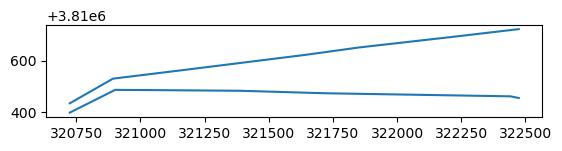

In [3]:
load_corridor_centerline(url, normalized_las_path).plot()
